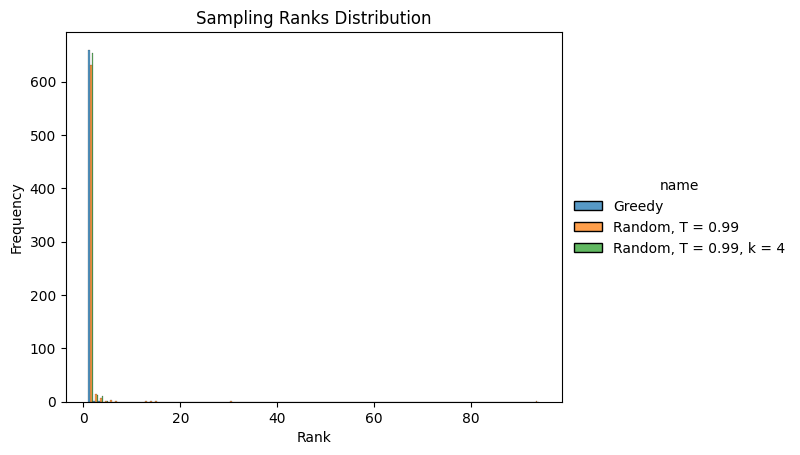

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_val_greed = []
with open(file='vllm_sampling_ranks_greedy.txt', mode='r') as f:
    lines = f.readlines()
    for l in lines:
        data_val_greed.append(int(l))

data_val_rand_T = []
with open(file='vllm_sampling_ranks_rand_t.txt', mode='r') as f:
    lines = f.readlines()
    for l in lines:
        data_val_rand_T.append(int(l))

data_val_rand_T_k = []
with open(file='vllm_sampling_ranks_rand_t_k.txt', mode='r') as f:
    lines = f.readlines()
    for l in lines:
        data_val_rand_T_k.append(int(l))

df = pd.concat(axis=0, ignore_index=True, objs=[
    pd.DataFrame.from_dict({'value': np.array(data_val_greed).T, 'name': 'Greedy'}),
    pd.DataFrame.from_dict({'value': np.array(data_val_rand_T).T, 'name': 'Random, T = 0.99'}),
    pd.DataFrame.from_dict({'value': np.array(data_val_rand_T_k).T, 'name': 'Random, T = 0.99, k = 4'})
])

fig, ax = plt.subplots()

# Create the histogram
sns.histplot(data=df, x='value', hue='name', multiple='dodge', ax=ax)
sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

plt.title('Sampling Ranks Distribution')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.show()


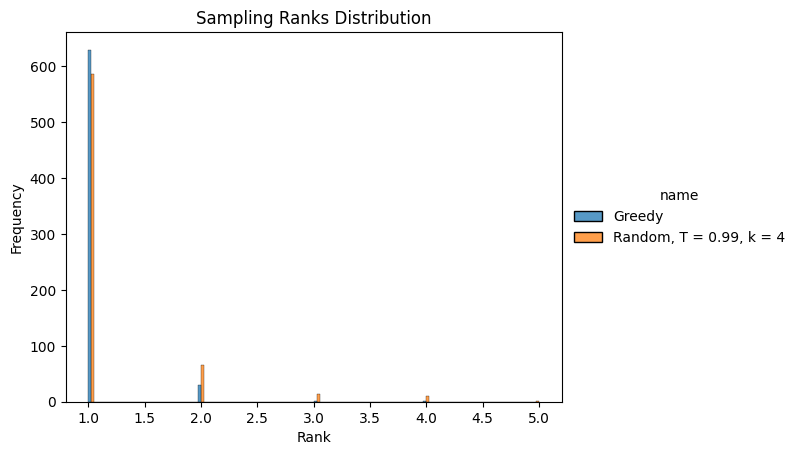

In [2]:
df = pd.concat(axis=0, ignore_index=True, objs=[
    pd.DataFrame.from_dict({'value': np.array(data_val_greed).T, 'name': 'Greedy'}),
    pd.DataFrame.from_dict({'value': np.array(data_val_rand_T_k).T, 'name': 'Random, T = 0.99, k = 4'})
])

fig, ax = plt.subplots()

# Create the histogram
sns.histplot(data=df, x='value', hue='name', multiple='dodge', ax=ax)
sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

plt.title('Sampling Ranks Distribution')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.show()

In [19]:
print(f"Random sampling with T = 0.99 and k = 4:\nNumber of ranks > k: {int((np.array(data_val_rand_T_k) > 4).sum(-1))} \nNumber of ranks > 1: {int((np.array(data_val_rand_T_k) > 1).sum(-1))} \nOverall number of tokens: {len(data_val_rand_T_k)} \nMaximum rank value: {max(data_val_rand_T_k)}")

Random sampling with T = 0.99 and k = 4:
Number of ranks > k: 1 
Number of ranks > 1: 91 
Overall number of tokens: 678 
Maximum rank value: 5


In [20]:
print(f"Random sampling with T = 0.99:\nNumber of ranks > k: {int((np.array(data_val_rand_T) > 4).sum(-1))} \nNumber of ranks > 1: {int((np.array(data_val_rand_T) > 1).sum(-1))} \nOverall number of tokens: {len(data_val_rand_T)} \nMaximum rank value: {max(data_val_rand_T)}")

Random sampling with T = 0.99:
Number of ranks > k: 12 
Number of ranks > 1: 100 
Overall number of tokens: 666 
Maximum rank value: 94


In [21]:
print(f"Greedy sampling:\nNumber of ranks > k: {int((np.array(data_val_greed) > 4).sum(-1))} \nNumber of ranks > 1: {int((np.array(data_val_greed) > 1).sum(-1))} \nOverall number of tokens: {len(data_val_greed)} \nMaximum rank value: {max(data_val_greed)}")

Greedy sampling:
Number of ranks > k: 0 
Number of ranks > 1: 33 
Overall number of tokens: 663 
Maximum rank value: 4
